<a href="https://colab.research.google.com/github/abuzar01440/AI-agents-/blob/main/intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



1.   **State**: The information moving through the system.
2.  **StateGraph**: The map showing where the information goes.

3.  **END**: The final stop where the program finishes.



In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 1. State (The Clipboard)
# We define what information the clipboard can hold.
class MyClipboard(TypedDict):
    text: str

# 2. The Nodes (The Workers)
# Worker 1 takes the clipboard and adds "Hello"
def worker_one(state: MyClipboard):
    current_text = state["text"]
    return {"text": current_text + " Hello"}

# Worker 2 takes the clipboard and adds "World!"
def worker_two(state: MyClipboard):
    current_text = state["text"]
    return {"text": current_text + " World!"}

# 3. StateGraph (The Map)
# We hand the blueprint of our clipboard to the map maker.
workflow = StateGraph(MyClipboard)

# Add our workers to the map
workflow.add_node("first_worker", worker_one)
workflow.add_node("second_worker", worker_two)

# 4. Connect the Assembly Line (START -> Worker 1 -> Worker 2 -> END)
workflow.add_edge(START, "first_worker")         # The line starts at Worker 1
workflow.add_edge("first_worker", "second_worker") # Worker 1 passes to Worker 2
workflow.add_edge("second_worker", END)          # Worker 2 passes to the finish line

# Compile (build) the factory
app = workflow.compile()

# --- Let's run it! ---

# We create our starting clipboard
starting_clipboard = {"text": "The computer says:"}

# We send it through the factory
final_result = app.invoke(starting_clipboard)

print(final_result)

{'text': 'The computer says: Hello World!'}


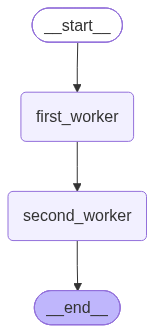

In [4]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))